# 03 — Trait surface analysis

**Research question:** Given a tree's functional traits (root depth `Zr`, leaf phenology `leaf_fraction`, canopy cover), can we predict whether it competes with or facilitates an associated crop — and how does local rainfall modulate that?

## Paper figure arc

| Fig | What it shows | Scientific purpose |
|-----|--------------|--------------------|
| 1 | Model schematic | Establish the physics (external, not in this notebook) |
| 2 | Single-season time series | Make the mechanisms tangible |
| 3 | Factorial decomposition | Rank mechanism contributions, motivate trait axes |
| 4 | **Trait surface** `leaf_fraction × Zr → ΔY` | Main result: competition-facilitation map |
| 5 | Rainfall modulation (3 × Fig 4) | How rainfall shifts the facilitation boundary |

**Status:** Figs 2–3 can run now. Figs 4–5 require continuous `Zr` sweep (model already supports it — just needs the grid loop).

**Output directory:** `../output/`

In [228]:
import nbformat, sys
sys.path.insert(0, '..')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import TwoSlopeNorm

# Load class-definition and helper cells from tree.ipynb
_nb = nbformat.read('../tree.ipynb', as_version=4)
for _cell in _nb.cells:
    if _cell.cell_type == 'code' and _cell.get('id', '') in {
        'c23f275b',   # core imports: numpy, farm classes, DataFrame, zeros
        '9adc45cd',   # Tree class
        '2149719d',   # shade_factor()
        '3bed3936',   # TreeCropModel
        '6jrb65spyt', # _m_yield, _b_yield
        'b2d38c76',   # run_one_season, season_metrics, _tree_sf
    }:
        src = _cell['source'].replace("'data/", "'../data/").replace('"data/', '"../data/')
        exec(src, globals())

def despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

print('Setup complete.')

Setup complete.


In [229]:
def _dY_array(tree_params, climate_obj, seeds, hr_max=1.0, s_deep_0=None, **run_kwargs):
    """Return array of (Y_tree_crop - Y_mono) for each seed.
    Paired simulations: same seed → same rainfall year for both models.
    run_kwargs (shade_on, hr_on, deep_roots) forwarded to model.run().
    """
    sf_ = _tree_sf(tree_params)
    lgp = 180
    out = []
    for seed in seeds:
        np.random.seed(seed)
        climate_obj.rainfall = Climate.generate(climate_obj.alpha_r, climate_obj.lambda_r)

        # monoculture
        s_m = Soil(texture='loam'); c_m = Crop(soil=s_m); c_m.lgp = lgp
        s_m.set_nZr(c_m)
        m_m = CropModel(crop=c_m, climate=climate_obj, soil=s_m)
        m_m.run()
        _, _, y_m, _ = season_metrics(c_m, m_m.output(), lgp)

        # tree-crop
        s_t = Soil(texture='loam'); c_t = Crop(soil=s_t); c_t.lgp = lgp
        tr_ = Tree(soil=s_t, **tree_params)
        m_t = TreeCropModel(crop=c_t, tree=tr_, climate=climate_obj, soil=s_t, hr_max=hr_max)
        m_t.run(s_deep_0=s_deep_0, **run_kwargs)
        _, _, y_t, _ = season_metrics(c_t, m_t.output(), lgp, sf=sf_)

        out.append(y_t - y_m)
    return np.array(out)


# Rainfall scales → mean annual rainfall (mm) for labels
# alpha=10 mm, lambda=0.25/day, 365 days → baseline ~912 mm
# rf_scale multiplies lambda: effective_mean = alpha * lambda * scale * 365
RF_SCALES   = [0.25, 0.35, 0.50, 0.70, 1.00, 1.40, 1.80]
RF_LABELS   = [f'{int(10 * s * 0.25 * 365)} mm' for s in RF_SCALES]

print('Helpers ready.')
print('Rainfall levels:', list(zip(RF_SCALES, RF_LABELS)))

Helpers ready.
Rainfall levels: [(0.25, '228 mm'), (0.35, '319 mm'), (0.5, '456 mm'), (0.7, '638 mm'), (1.0, '912 mm'), (1.4, '1277 mm'), (1.8, '1642 mm')]


---
## Fig 2 — Single-season time series

**Purpose:** Make the physics tangible before showing statistics.

Show one representative growing season (same rainfall year) for:
- Monoculture crop
- Tree-crop system (full mechanisms: deep roots + HR + shade)

**4-panel layout:**
- Top-left: `s_top` (monoculture vs tree-crop)
- Top-right: `s_deep` (tree-exclusive zone)
- Bottom-left: `T_crop` (monoculture vs tree-crop) — shows competition signal
- Bottom-right: `HR` flux — shows the facilitation mechanism in action

**Tree:** Faidherbia-like (lf=0.0, Zr=1500) — most illustrative because HR is clearest when tree is dormant in-season.

In [230]:
# Fixed seed for reproducibility — pick one that shows clear HR activity
SEED_FIG2 = 42
lgp = 180

tree_params_fig2 = dict(
    Zr=1500, T_MAX=2.0, kc=1.0, canopy_cover=0.2,
    sw_MPa=-2.0, s_star_MPa=-0.1, leaf_fraction=1.0   # lf=1: evergreen
)

climate_fig2 = Climate()
np.random.seed(SEED_FIG2)
climate_fig2.rainfall = Climate.generate(climate_fig2.alpha_r, climate_fig2.lambda_r)

# Monoculture
s_m = Soil(texture='loam'); c_m = Crop(soil=s_m); c_m.lgp = lgp
s_m.set_nZr(c_m)
m_m = CropModel(crop=c_m, climate=climate_fig2, soil=s_m)
m_m.run()
df_mono = m_m.output()

# Tree-crop (full mechanisms)
s_t = Soil(texture='loam'); c_t = Crop(soil=s_t); c_t.lgp = lgp
tr_ = Tree(soil=s_t, **tree_params_fig2)
m_t = TreeCropModel(crop=c_t, tree=tr_, climate=climate_fig2, soil=s_t, hr_max=1.0)
m_t.run(shade_on=True, hr_on=True, deep_roots=True)
df_tree = m_t.output()

# Crop season only
df_mono_s = df_mono.iloc[:lgp]
df_tree_s = df_tree.iloc[:lgp]

print('Monoculture columns:', df_mono.columns.tolist())
print('Tree-crop columns:  ', df_tree.columns.tolist())

Monoculture columns: ['kc', 'LAI', 'stress', 'R', 's', 'I', 'E', 'ET', 'T', 'L', 'dsdt', 'dos', 'doy']
Tree-crop columns:   ['kc', 'kc_tree', 'LAI', 'stress', 'R', 's_top', 's_deep', 'I', 'Q', 'E', 'T_crop', 'T_tree', 'ET_crop', 'ET_tree', 'ET', 'HR', 'L', 'dsdt', 'dos', 'doy', 'T_tree_top', 'T_tree_deep']


In [231]:
# Find a representative seed: closest to median seasonal rainfall
lgp = 180
scan_climate = Climate()
seasonal_rf = {}

for seed in range(200):
    np.random.seed(seed)
    rf = Climate.generate(scan_climate.alpha_r, scan_climate.lambda_r)
    seasonal_rf[seed] = rf[:lgp].sum()

rf_vals   = np.array(list(seasonal_rf.values()))
rf_median = np.median(rf_vals)
rf_mean   = rf_mean = rf_vals.mean()

print(f'Seasonal rainfall (180-day):  mean={rf_mean:.0f} mm  median={rf_median:.0f} mm')
print(f'Seed 42 rainfall: {seasonal_rf[42]:.0f} mm  (percentile: {100*np.mean(rf_vals <= seasonal_rf[42]):.0f}th)')
print()

# Top 5 seeds closest to the median
dists = {s: abs(v - rf_median) for s, v in seasonal_rf.items()}
top5  = sorted(dists, key=dists.get)[:5]
print('Seeds closest to median:')
for s in top5:
    print(f'  seed={s:3d}  rainfall={seasonal_rf[s]:.0f} mm')

Seasonal rainfall (180-day):  mean=452 mm  median=444 mm
Seed 42 rainfall: 412 mm  (percentile: 36th)

Seeds closest to median:
  seed= 10  rainfall=445 mm
  seed= 29  rainfall=443 mm
  seed= 50  rainfall=445 mm
  seed=189  rainfall=446 mm
  seed=141  rainfall=440 mm


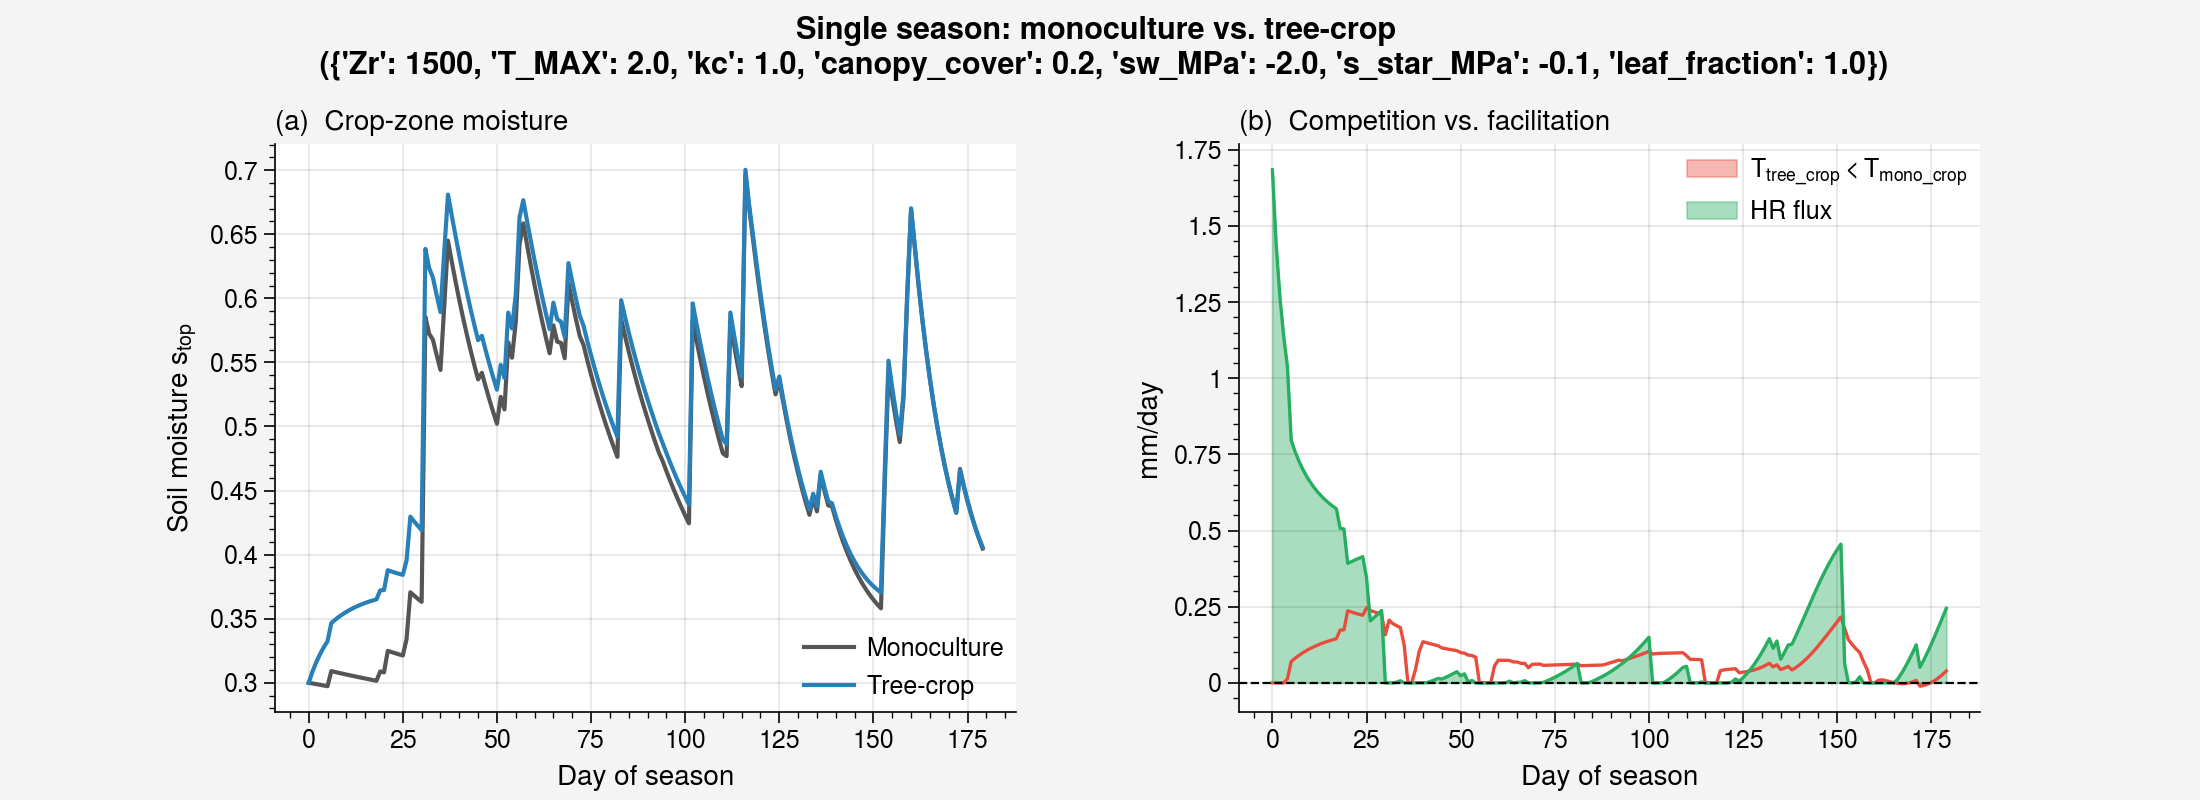

In [232]:
fig, (ax_a, ax_f) = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
fig.subplots_adjust(wspace=0.3, top=0.82)
days = np.arange(lgp)

C_MONO = '#555555'
C_TREE = '#2980b9'
C_HR   = '#27ae60'
C_COMP = '#e74c3c'

# (a) Crop-zone moisture
ax_a.plot(days, df_mono_s['s'].values,     color=C_MONO, lw=1.5, label='Monoculture')
ax_a.plot(days, df_tree_s['s_top'].values, color=C_TREE, lw=1.5, label='Tree-crop')
ax_a.set_ylabel('Soil moisture $s_{top}$', fontsize=10)
ax_a.set_xlabel('Day of season', fontsize=10)
ax_a.set_title('(a)  Crop-zone moisture', fontsize=10, loc='left')
ax_a.legend(fontsize=9, frameon=False)
despine(ax_a)

# (f) Competition vs. facilitation
dT_crop = df_tree_s['T_crop'].values - df_mono_s['T'].values
ax_f.fill_between(days, dT_crop, where=(dT_crop < 0), alpha=0.4, color=C_COMP, label='$T_{tree\_crop} < T_{mono\_crop}$')
ax_f.fill_between(days, df_tree_s['HR'].values, alpha=0.4, color=C_HR, label='HR flux')
ax_f.plot(days, dT_crop,                color=C_COMP, lw=1.2)
ax_f.plot(days, df_tree_s['HR'].values, color=C_HR,   lw=1.2)
ax_f.axhline(0, color='k', lw=0.8, ls='--')
ax_f.set_ylabel('mm/day', fontsize=10)
ax_f.set_xlabel('Day of season', fontsize=10)
ax_f.set_title('(b)  Competition vs. facilitation', fontsize=10, loc='left')
ax_f.legend(fontsize=9, frameon=False)
despine(ax_f)

lf_val = tree_params_fig2['leaf_fraction']
fig.suptitle(f'Single season: monoculture vs. tree-crop \n ({tree_params_fig2})', fontsize=11)
plt.savefig('../output/fig2_single_season.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 3 — Factorial mechanism decomposition

**Purpose:** Rank mechanism contributions to ΔY before generalizing across trait space.

**Design:** Single deep-rooted, evergreen tree (lf=1.0, Zr=1500 — no phenological advantage). N=200 paired seasons. Each bar adds one mechanism cumulatively:

1. Baseline: shallow competition only (no deep roots, no HR, no shade)
2. +Deep roots (tree draws from deep zone first)
3. +HR (nocturnal hydraulic lift)
4. +Shade (reduces E; PAR penalty via sf)

**Key expected finding:** Deep roots is the dominant facilitation mechanism. This motivates `Zr` as the primary trait axis in Fig 4.

**Rainfall:** Baseline regime (rf_scale=1.0).

In [233]:
N = 200
seeds = np.arange(N)
climate_fig3 = Climate()  # baseline regime

# Deep-rooted evergreen: isolates mechanism effects without phenological advantage
tp = dict(Zr=1500, T_MAX=2.0, kc=1.0, canopy_cover=0.2,
          sw_MPa=-2.0, s_star_MPa=-0.1, leaf_fraction=1.0)

# Cumulative mechanism stack
dY_shallow = _dY_array(tp, climate_fig3, seeds, shade_on=False, hr_on=False, deep_roots=False)
dY_deep    = _dY_array(tp, climate_fig3, seeds, shade_on=False, hr_on=False, deep_roots=True)
dY_hr      = _dY_array(tp, climate_fig3, seeds, shade_on=False, hr_on=True,  deep_roots=True)
dY_full    = _dY_array(tp, climate_fig3, seeds, shade_on=True,  hr_on=True,  deep_roots=True)

medians = [np.median(x) for x in [dY_shallow, dY_deep, dY_hr, dY_full]]
q25     = [np.percentile(x, 25) for x in [dY_shallow, dY_deep, dY_hr, dY_full]]
q75     = [np.percentile(x, 75) for x in [dY_shallow, dY_deep, dY_hr, dY_full]]

labels = ['Shallow\ncompetition\nonly', '+Deep\nroots', '+HR', '+Shade']
for lbl, med, lo, hi in zip(labels, medians, q25, q75):
    print(f'{lbl.replace(chr(10)," "):30s}  median={med:+.0f}  IQR=[{lo:+.0f}, {hi:+.0f}]')

Shallow competition only        median=-40  IQR=[-55, -30]
+Deep roots                     median=-46  IQR=[-66, -31]
+HR                             median=+41  IQR=[+4, +87]
+Shade                          median=+102  IQR=[+54, +191]


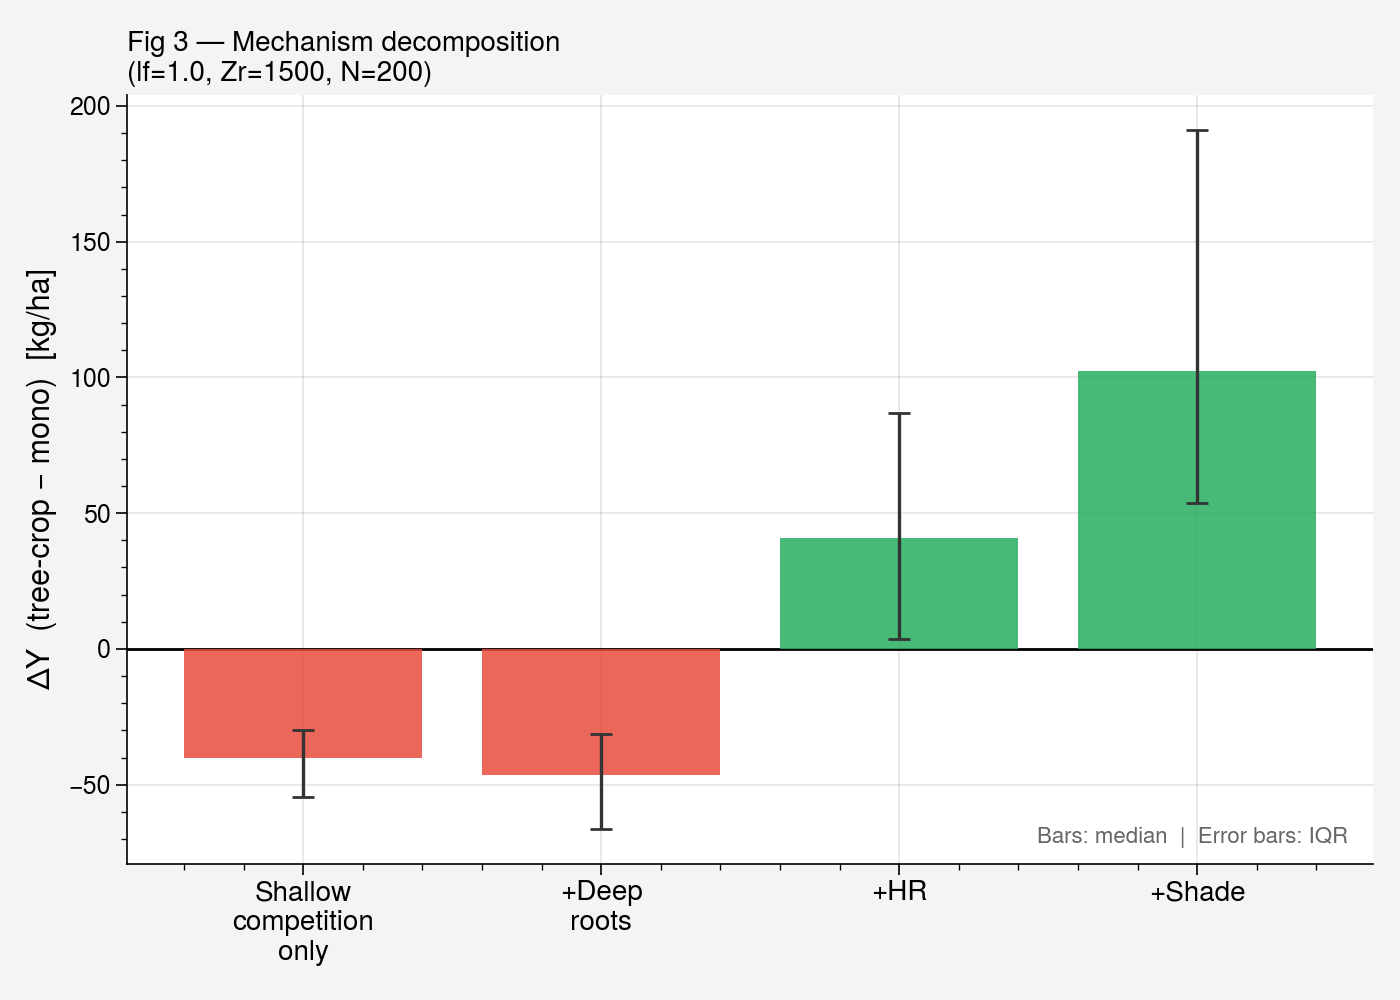

In [234]:
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(labels))
colors = ['#e74c3c' if m < 0 else '#27ae60' for m in medians]
yerr_lo = [m - lo for m, lo in zip(medians, q25)]
yerr_hi = [hi - m for m, hi in zip(medians, q75)]

bars = ax.bar(x, medians, color=colors, alpha=0.85, zorder=3,
              yerr=[yerr_lo, yerr_hi], error_kw=dict(ecolor='#333333', capsize=4, lw=1.2))
ax.axhline(0, color='k', lw=1, zorder=2)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('ΔY  (tree-crop − mono)  [kg/ha]', fontsize=11)
ax.set_title('Fig 3 — Mechanism decomposition\n(lf=1.0, Zr=1500, N=200)', fontsize=10, loc='left')
ax.text(0.98, 0.02, 'Bars: median  |  Error bars: IQR',
        transform=ax.transAxes, ha='right', va='bottom', fontsize=8, color='#666666')
despine(ax)

plt.tight_layout()
plt.savefig('../output/fig3_factorial.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig — Mechanisms

**Purpose:** Show the isolated effect of each physically coherent mechanism on ΔY.
Each bar = one mechanism switched on, all others off. ΔY=0 is the reference (no tree effect).

**Design:** moderate season (~450 mm/season), lf=1 (evergreen), Zr=1500, T_MAX=2.0, N=200.

| Bar | What is on | Physical interpretation |
|-----|-----------|------------------------|
| Root zone separation | deep_roots=True | Tree demand routed to s_deep → s_top reserved for crop |
| Hydraulic redistribution | deep_roots + hr_on | Nocturnal water lift from s_deep → s_top |
| Canopy shade | shade_on=True + sf<1 | Net canopy effect: evaporation reduction (good) vs PAR blockage (bad) |
| Full system | all on | Net effect of all mechanisms combined |

In [235]:
def _dY_sf(tree_params, climate_obj, seeds, sf_override=None, **run_kwargs):
    """Like _dY_array but sf_override lets us decouple the shade yield penalty
    from _tree_sf(tree_params), so we can isolate PAR vs E shade effects."""
    sf_ = sf_override if sf_override is not None else _tree_sf(tree_params)
    lgp = 180
    out = []
    for seed in seeds:
        np.random.seed(seed)
        climate_obj.rainfall = Climate.generate(climate_obj.alpha_r, climate_obj.lambda_r)

        s_m = Soil(texture='loam'); c_m = Crop(soil=s_m); c_m.lgp = lgp
        s_m.set_nZr(c_m)
        m_m = CropModel(crop=c_m, climate=climate_obj, soil=s_m)
        m_m.run()
        _, _, y_m, _ = season_metrics(c_m, m_m.output(), lgp)

        s_t = Soil(texture='loam'); c_t = Crop(soil=s_t); c_t.lgp = lgp
        tr_ = Tree(soil=s_t, **tree_params)
        m_t = TreeCropModel(crop=c_t, tree=tr_, climate=climate_obj, soil=s_t, hr_max=1.0)
        m_t.run(**run_kwargs)
        _, _, y_t, _ = season_metrics(c_t, m_t.output(), lgp, sf=sf_)
        out.append(y_t - y_m)
    return np.array(out)


N_MECH    = 200
seeds_m   = np.arange(N_MECH)
climate_m = Climate()   # baseline regime (rf_scale=1.0, ~450 mm/season)

tp_mech = dict(
    Zr=1500, T_MAX=2.0, kc=1.0, canopy_cover=0.2,
    sw_MPa=-2.0, s_star_MPa=-0.1, leaf_fraction=1.0,
)
sf_mech = _tree_sf(tp_mech)

print(f'Shade factor sf = {sf_mech:.3f}')
print(f'Plot-level tree T_MAX = {tp_mech["T_MAX"] * tp_mech["canopy_cover"]:.2f} mm/day')

# Each bar = one physically coherent mechanism switched on in isolation.
# Canopy shade combines both sub-effects (E reduction + PAR penalty) because
# a real canopy produces both simultaneously — they cannot be separated in nature.
configs = [
    ('Root zone\nseparation',     dict(shade_on=False, hr_on=False, deep_roots=True),  1.0),
    ('Hydraulic\nredistribution', dict(shade_on=False, hr_on=True,  deep_roots=True),  1.0),
    ('Canopy\nshade',             dict(shade_on=True,  hr_on=False, deep_roots=False), sf_mech),
    ('Full\nsystem',              dict(shade_on=True,  hr_on=True,  deep_roots=True),  sf_mech),
]

mech_results = {}
for label, run_kw, sf_ov in configs:
    arr = _dY_sf(tp_mech, climate_m, seeds_m, sf_override=sf_ov, **run_kw)
    mech_results[label] = arr
    print(f'{label.replace(chr(10)," "):28s}  '
          f'median={np.median(arr):+6.0f}  IQR=[{np.percentile(arr,25):+.0f}, {np.percentile(arr,75):+.0f}]')

Shade factor sf = 0.887
Plot-level tree T_MAX = 0.40 mm/day
Root zone separation          median=   -30  IQR=[-57, -13]
Hydraulic redistribution      median=   +58  IQR=[+17, +97]
Canopy shade                  median=   +15  IQR=[-0, +40]
Full system                   median=  +102  IQR=[+54, +191]


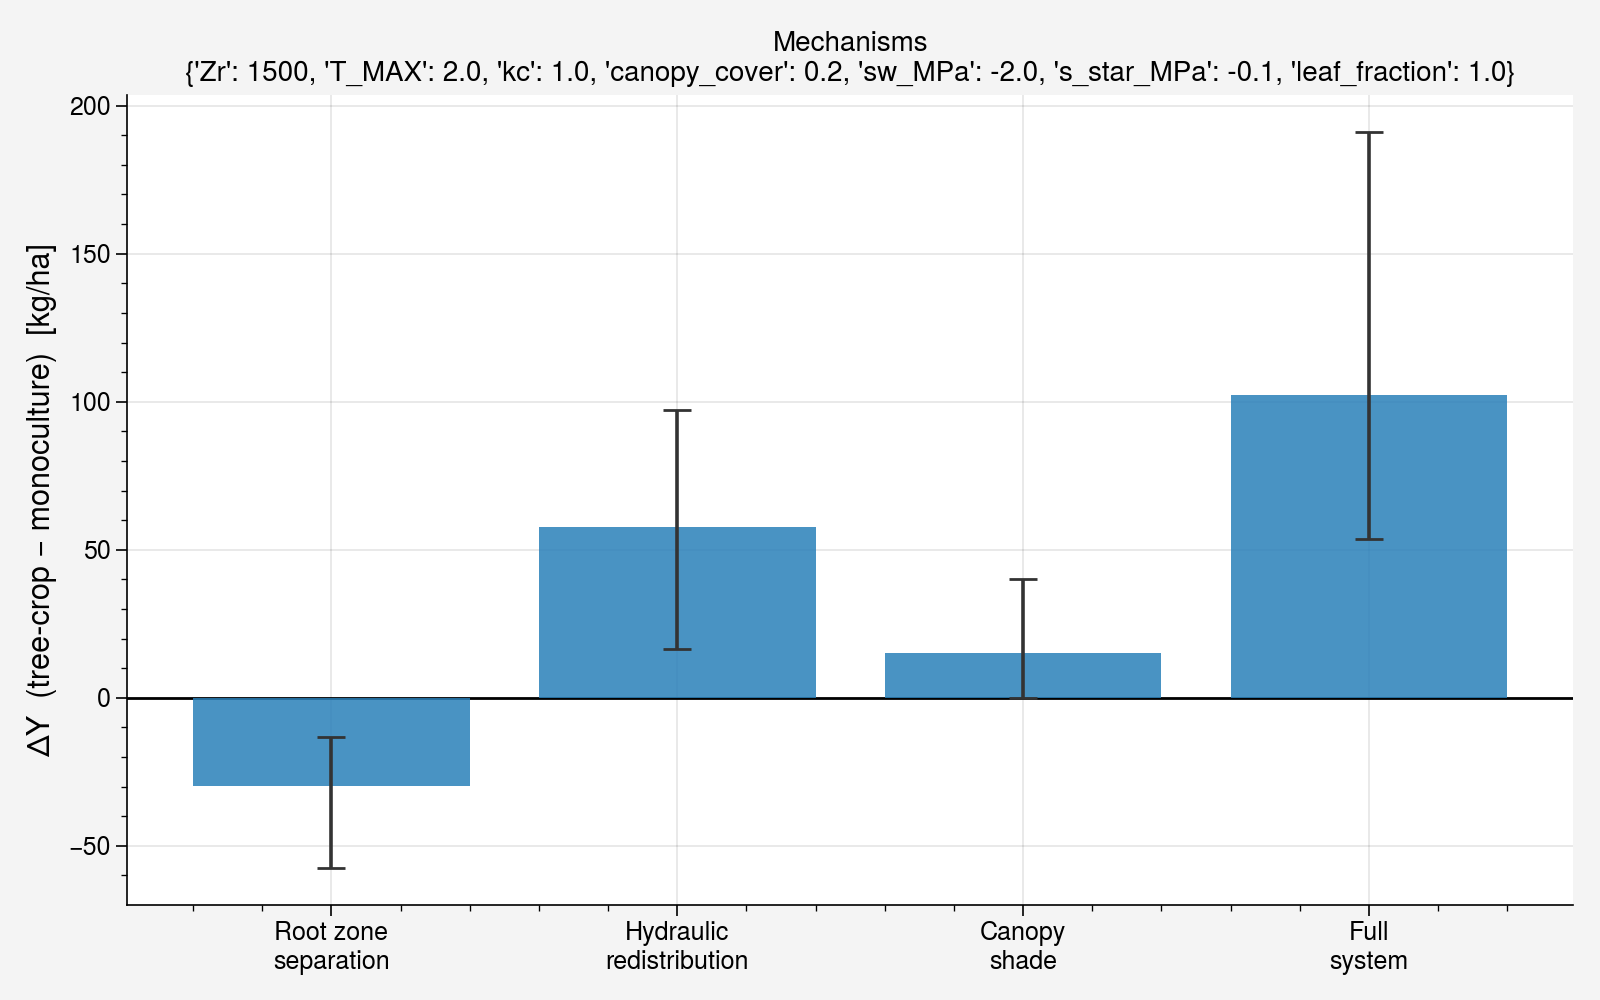

In [236]:
labels  = list(mech_results.keys())
medians = [np.median(v) for v in mech_results.values()]
q25     = [np.percentile(v, 25) for v in mech_results.values()]
q75     = [np.percentile(v, 75) for v in mech_results.values()]
yerr_lo = [m - lo for m, lo in zip(medians, q25)]
yerr_hi = [hi - m for m, hi in zip(medians, q75)]

colors = ['#2980b9' if 'Full' in lbl else ('#2980b9' if m >= 0 else '#2980b9')
          for lbl, m in zip(labels, medians)]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x, medians, color=colors, alpha=0.85, zorder=3,
       yerr=[yerr_lo, yerr_hi],
       error_kw=dict(ecolor='#333333', capsize=5, lw=1.3))
ax.axhline(0, color='k', lw=1.0, zorder=2)



ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel('ΔY  (tree-crop − monoculture)  [kg/ha]', fontsize=11)
ax.set_title(
    f'Mechanisms\n{tp_mech}',
    fontsize=10
)

despine(ax)

plt.tight_layout()
plt.savefig('../output/fig_mechanisms.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 4 — Trait surface  (`leaf_fraction × Zr → ΔY`)

**Purpose:** The main result. Map the competition-facilitation boundary across continuous trait space.

**Design:**
- X-axis: `leaf_fraction` ∈ {0.0, 0.2, 0.4, 0.6, 0.8, 1.0}  (0 = fully dormant in-season; 1 = evergreen)
- Y-axis: `Zr` ∈ {600, 800, 1000, 1200, 1500, 1800} mm  (shallow → deep roots)
- Color: median ΔY across N=200 paired seasons
- Diverging colormap centered on 0 (red = competition, blue = facilitation)
- Zero-contour explicitly drawn
- Labeled points: Faidherbia (lf=0.0, Zr=1500), Grevillea (lf=1.0, Zr=700), Leucaena (lf=0.9, Zr=1200)

**Mechanisms:** Full system (deep roots + HR + shade) for all cells.

**Rainfall:** Baseline regime (rf_scale=1.0). See Fig 5 for rainfall modulation.

⚠️ **TODO:** `Zr` sweep requires no model changes — `TreeCropModel` already accepts any `Zr > Zr_crop`.
This cell is ready to run once you confirm the model handles e.g. `Zr=800` correctly.

In [177]:
# Trait axes
LF_VALS = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
ZR_VALS = list(range(600, 2100, 100))   # 600, 700, …, 2000 mm (15 values)

# Fixed parameters (held constant across the surface)
# T_MAX=2.0: plot-level tree demand = T_MAX × canopy_cover = 2.0 × 0.2 = 0.4 mm/day.
# Represents a moderate-demand agroforestry tree (~50% of crop T_MAX per canopy area).
BASE_PARAMS = dict(
    T_MAX=2.0,
    kc=1.0,
    canopy_cover=0.2,
    sw_MPa=-2.0,
    s_star_MPa=-0.1,
)

# Species overlay — trait estimates from literature
# Faidherbia albida: reverse phenology (lf=0), phreatophyte (Zr=1500mm vadose zone proxy).
#   Iconic facilitator; not typical highland Kenya but useful as facilitation reference.
#   Source: Roupsard et al. 1999; Sarr et al. 2023
# Grevillea robusta: evergreen (lf=1), predominantly deep-rooting but competitive with crop
#   (~700–1000mm effective competition zone). Most planted agroforestry tree in highland Kenya.
#   Source: Ong et al. 2000 (Ag. Ecosys. Env. 80); root distribution studies in Plant & Soil
# Alnus acuminata: semi-deciduous, sheds leaves late dry season (lf≈0.7), N-fixer,
#   moderate root depth. Common in E. African highland agroforestry.
#   Source: Ong et al. 2005 (For. Ecol. Mgmt.)
SPECIES = {
    'Faidherbia':  dict(lf=0.0, Zr=1500, color='#2ecc71', marker='*', ms=14),
    'Grevillea':   dict(lf=1.0, Zr=800,  color='#e74c3c', marker='s', ms=10),
    'Alnus':       dict(lf=0.7, Zr=1000, color='#f39c12', marker='^', ms=10),
}

N_GRID = 200   # paired seasons per cell — increase to 300 for final paper
seeds  = np.arange(N_GRID)
climate_fig4 = Climate()   # baseline

print(f'Grid size: {len(LF_VALS)} × {len(ZR_VALS)} = {len(LF_VALS)*len(ZR_VALS)} cells')
print(f'Simulations: {len(LF_VALS)*len(ZR_VALS)*N_GRID*2:,} total model runs')
print(f'Zr range: {ZR_VALS[0]}–{ZR_VALS[-1]} mm  (Δ = 100 mm/step)')
print(f'Tree plot-level T_MAX: {BASE_PARAMS["T_MAX"] * BASE_PARAMS["canopy_cover"]:.1f} mm/day')

Grid size: 6 × 15 = 90 cells
Simulations: 36,000 total model runs
Zr range: 600–2000 mm  (Δ = 100 mm/step)
Tree plot-level T_MAX: 0.4 mm/day


In [178]:
# ── Compute ΔY for each (lf, Zr) cell ─────────────────────────────────────
# shape: (len(ZR_VALS), len(LF_VALS))  — rows = Zr (y-axis), cols = lf (x-axis)

surface_median = np.full((len(ZR_VALS), len(LF_VALS)), np.nan)
surface_frac   = np.full((len(ZR_VALS), len(LF_VALS)), np.nan)  # fraction facilitative

for i, zr in enumerate(ZR_VALS):
    for j, lf in enumerate(LF_VALS):
        tp = {**BASE_PARAMS, 'Zr': zr, 'leaf_fraction': lf}
        dY = _dY_array(tp, climate_fig4, seeds,
                       shade_on=True, hr_on=True, deep_roots=True)
        surface_median[i, j] = np.median(dY)
        surface_frac[i, j]   = np.mean(dY > 0)
        print(f'  Zr={zr:4d}  lf={lf:.1f}  median ΔY={np.median(dY):+.0f}  frac={np.mean(dY>0):.2f}')

print('\nGrid complete.')

  Zr= 600  lf=0.0  median ΔY=+59  frac=0.80
  Zr= 600  lf=0.2  median ΔY=+22  frac=0.56
  Zr= 600  lf=0.4  median ΔY=+0  frac=0.41
  Zr= 600  lf=0.6  median ΔY=-24  frac=0.23
  Zr= 600  lf=0.8  median ΔY=-50  frac=0.12
  Zr= 600  lf=1.0  median ΔY=-66  frac=0.10
  Zr= 700  lf=0.0  median ΔY=+85  frac=0.86
  Zr= 700  lf=0.2  median ΔY=+54  frac=0.70
  Zr= 700  lf=0.4  median ΔY=+14  frac=0.55
  Zr= 700  lf=0.6  median ΔY=+0  frac=0.41
  Zr= 700  lf=0.8  median ΔY=-20  frac=0.29
  Zr= 700  lf=1.0  median ΔY=-34  frac=0.22
  Zr= 800  lf=0.0  median ΔY=+105  frac=0.88
  Zr= 800  lf=0.2  median ΔY=+82  frac=0.84
  Zr= 800  lf=0.4  median ΔY=+53  frac=0.69
  Zr= 800  lf=0.6  median ΔY=+20  frac=0.57
  Zr= 800  lf=0.8  median ΔY=+0  frac=0.46
  Zr= 800  lf=1.0  median ΔY=-1  frac=0.39
  Zr= 900  lf=0.0  median ΔY=+118  frac=0.88
  Zr= 900  lf=0.2  median ΔY=+101  frac=0.86
  Zr= 900  lf=0.4  median ΔY=+74  frac=0.83
  Zr= 900  lf=0.6  median ΔY=+46  frac=0.69
  Zr= 900  lf=0.8  median ΔY=+19 

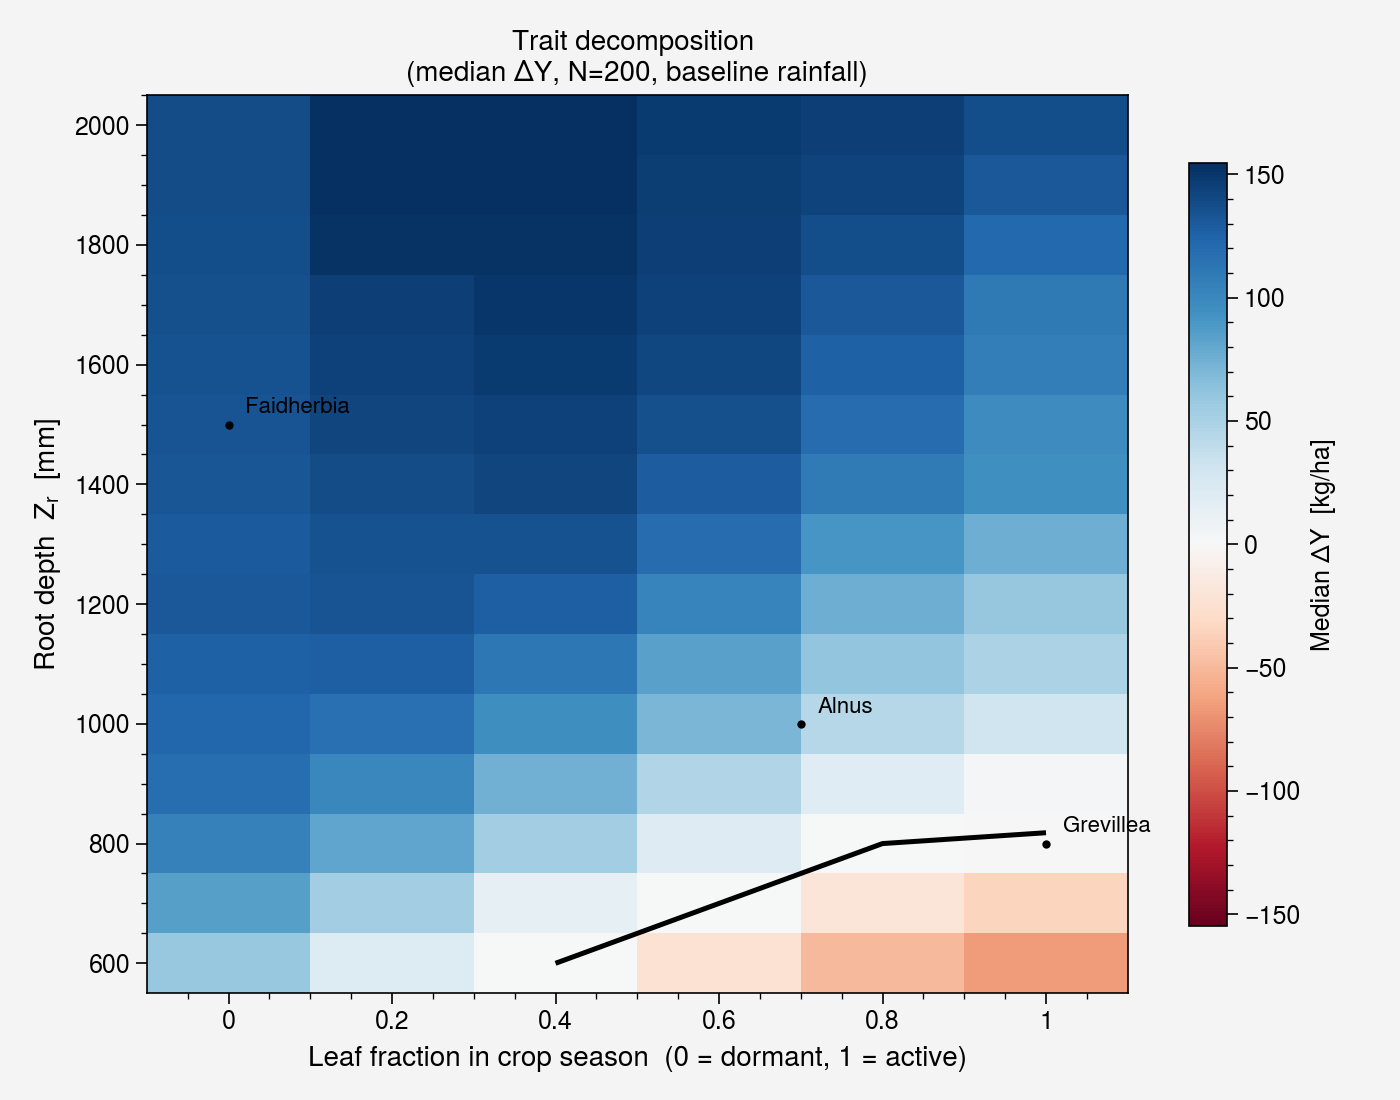

In [203]:
lf_arr = np.array(LF_VALS)
zr_arr = np.array(ZR_VALS)

fig, ax = plt.subplots(figsize=(7, 5.5))

vmax = np.nanmax(np.abs(surface_median))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.cm.RdBu  # red = competition, blue = facilitation

im = ax.pcolormesh(lf_arr, zr_arr, surface_median,
                   norm=norm, cmap=cmap, shading='nearest')

# Zero contour
ax.contour(lf_arr, zr_arr, surface_median, levels=[0],
           colors='k', linewidths=1.8)

ax.set_xlabel('Leaf fraction in crop season  (0 = dormant, 1 = active)', fontsize=10)
ax.set_ylabel('Root depth  $Z_r$  [mm]', fontsize=10)
ax.set_title('Trait decomposition \n(median ΔY, N=200, baseline rainfall)', fontsize=10)

# Species overlay at exact (lf, Zr) coordinates
# for name, sp in SPECIES.items():
#     ax.plot(sp['lf'], sp['Zr'], marker=sp['marker'], color=sp['color'],
#             ms=sp['ms'], mec='k', mew=0.8, zorder=5)
#     ax.annotate(name, (sp['lf'], sp['Zr']), textcoords='offset points', xytext=(6, 4),
#                 fontsize=8, color=sp['color'], fontweight='bold')
for name, sp in SPECIES.items():
    ax.plot(sp['lf'], sp['Zr'], marker='o', color='k',
            ms=3, mec='k', mew=0, zorder=5)

    ax.annotate(name, (sp['lf'], sp['Zr']),
                textcoords='offset points', xytext=(6, 4),
                fontsize=8, color='k')

plt.colorbar(im, ax=ax, label='Median ΔY  [kg/ha]', shrink=0.85)
plt.tight_layout()
plt.savefig('../output/fig4_trait_surface.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 5 — Rainfall modulation of the trait surface

**Purpose:** Show how the competition-facilitation boundary shifts across rainfall regimes.

**Design:** Three panels, each replicating Fig 4 at a different rainfall level:
- Left:   Dry      (~338 mm/season, rf_scale=0.75) — near crop failure threshold (43% zero-yield seasons in monoculture)
- Centre: Moderate (~450 mm/season, rf_scale=1.00) — baseline regime, Y_mono ≈ 1700 kg/ha
- Right:  Wet      (~562 mm/season, rf_scale=1.25) — high yield, Y_mono ≈ 2200 kg/ha

Zero-contour drawn on each panel in black. Colormap range fixed across panels for comparability.
Species overlay on each panel.

**Scale selection:** Based on rainfall sensitivity scan (`t42r61s1to`). Crop yield is zero below
~270 mm/season; interesting variation in ΔY begins at ~338 mm/season (scale=0.75). Scales 0.75/1.00/1.25
span the full transition from stress-limited to supply-limited regime.

**Key question to answer:** Does facilitation expand or contract with rainfall? Does the contour move up
(deeper roots needed) or left (less phenological constraint needed)?

⚠️ **Depends on Fig 4 compute cell.** Run Fig 4 first, then run this.

rf=  90 mm  Y_mono=    0  Y_tree=    0  ΔY=   +0
rf= 135 mm  Y_mono=    0  Y_tree=    0  ΔY=   +0
rf= 180 mm  Y_mono=    0  Y_tree=    0  ΔY=   +0
rf= 225 mm  Y_mono=    0  Y_tree=    0  ΔY=   +0
rf= 270 mm  Y_mono=    0  Y_tree=    0  ΔY=   +0
rf= 338 mm  Y_mono=  307  Y_tree=  673  ΔY= +111
rf= 450 mm  Y_mono= 1697  Y_tree= 1867  ΔY= +100
rf= 562 mm  Y_mono= 2172  Y_tree= 2218  ΔY=  +40
rf= 675 mm  Y_mono= 2374  Y_tree= 2385  ΔY=  +12
rf= 810 mm  Y_mono= 2557  Y_tree= 2515  ΔY=  -26


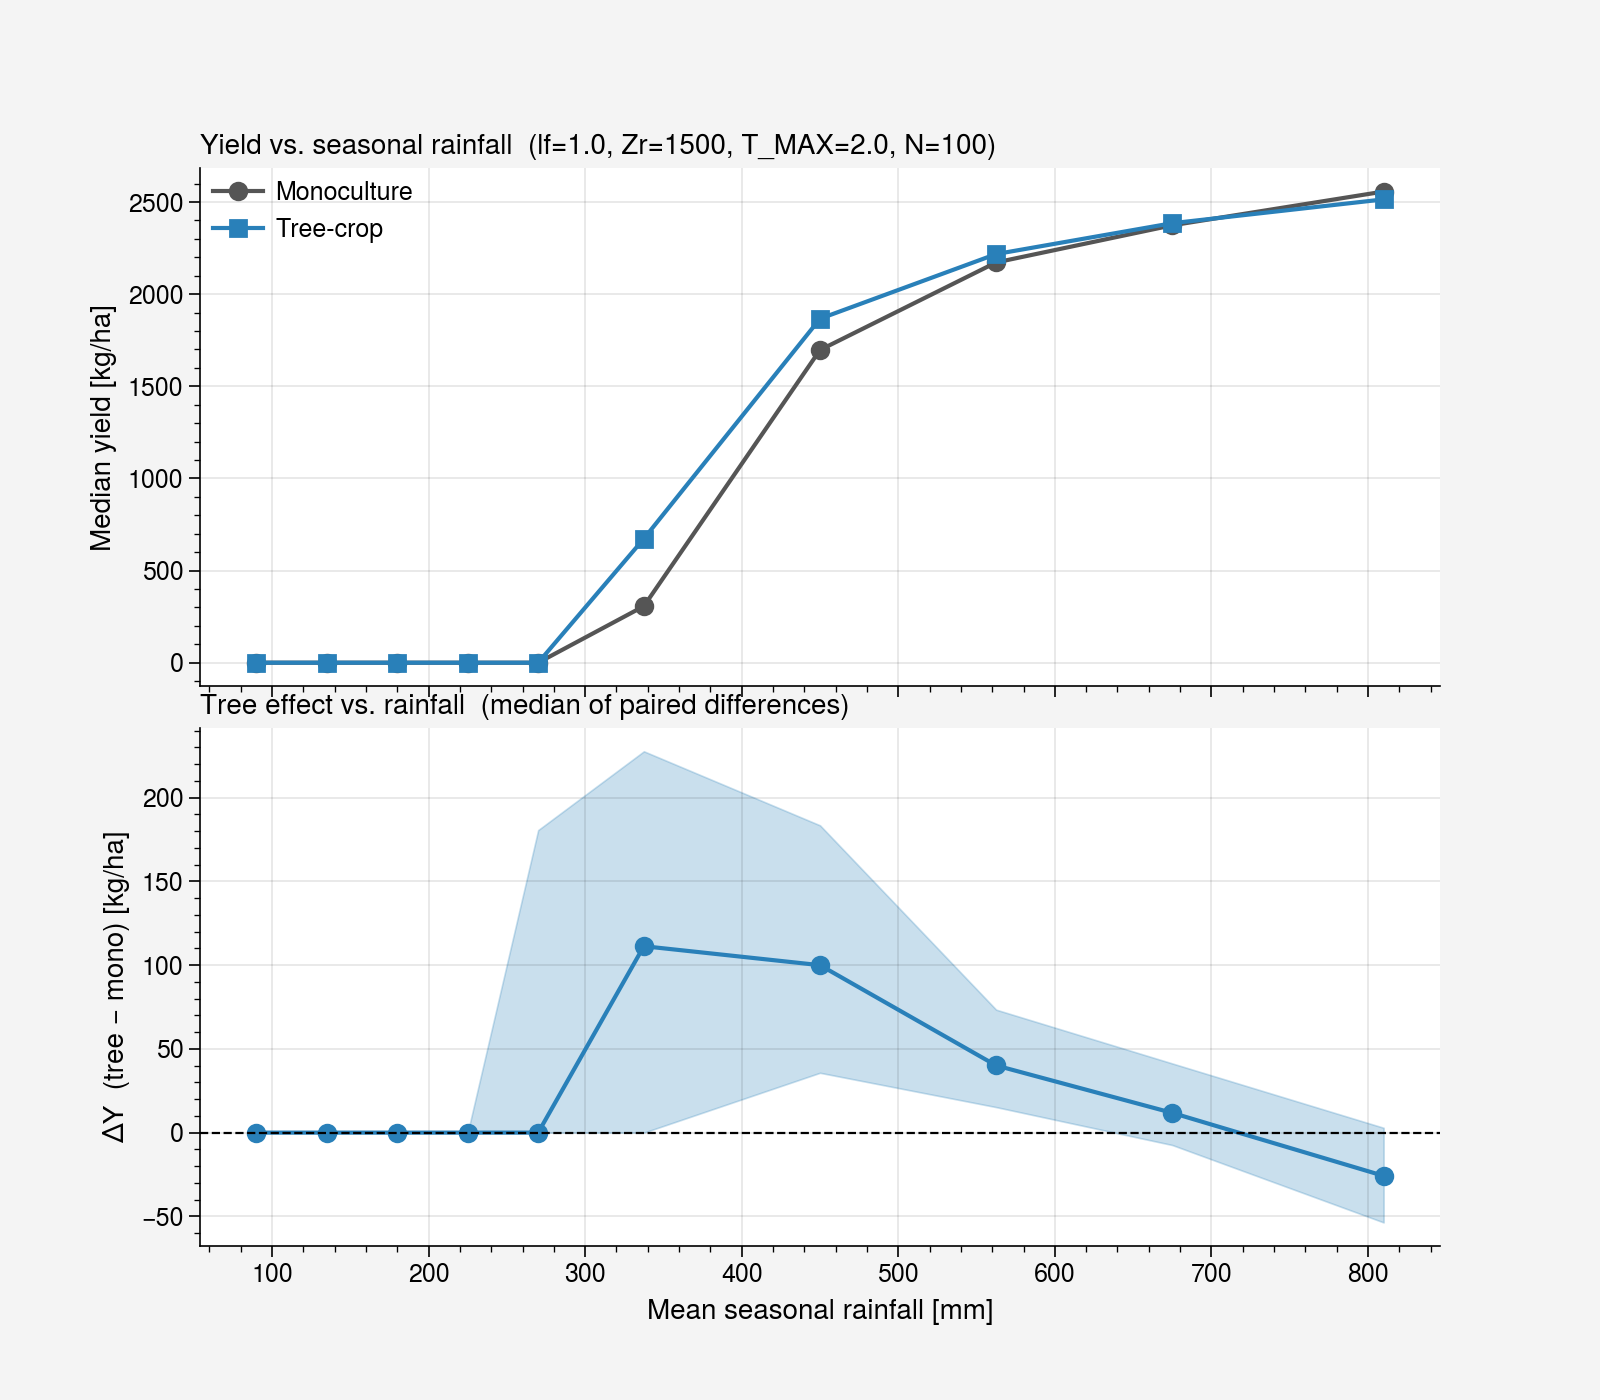


Candidate regime scales for Fig 5:
  ~300 mm: rf_scale=0.60  Y_mono=0  ΔY=+0
  ~400 mm: rf_scale=1.00  Y_mono=1697  ΔY=+100
  ~500 mm: rf_scale=1.00  Y_mono=1697  ΔY=+100


In [180]:
# ── Rainfall sensitivity: where does the tree actually matter? ────────────────
RF_SCALES_SWEEP = [0.20, 0.30, 0.40, 0.50, 0.60, 0.75, 1.00, 1.25, 1.50, 1.80]
N_SW     = 100
seeds_sw = np.arange(N_SW)
lgp      = 180

tp_sw = {**BASE_PARAMS, 'Zr': 1500, 'leaf_fraction': 1.0}
sf_sw = _tree_sf(tp_sw)

rows = []
for scale in RF_SCALES_SWEEP:
    climate_sw = Climate()
    climate_sw.lambda_r = np.array([0.25 * scale] * 365)
    mean_rf = 10 * 0.25 * scale * 180  # mm/season

    y_monos = []
    for seed in seeds_sw:
        np.random.seed(seed)
        climate_sw.rainfall = Climate.generate(climate_sw.alpha_r, climate_sw.lambda_r)
        s_m = Soil(texture='loam'); c_m = Crop(soil=s_m); c_m.lgp = lgp
        s_m.set_nZr(c_m)
        m_m = CropModel(crop=c_m, climate=climate_sw, soil=s_m)
        m_m.run()
        _, _, y_m, _ = season_metrics(c_m, m_m.output(), lgp)
        y_monos.append(y_m)

    dY_arr = _dY_array(tp_sw, climate_sw, seeds_sw,
                       shade_on=True, hr_on=True, deep_roots=True)

    y_trees = np.array(y_monos) + dY_arr
    rows.append(dict(
        rf_scale=float(scale),
        mean_rf=float(mean_rf),
        y_mono=float(np.median(y_monos)),
        y_tree=float(np.median(y_trees)),
        dY=float(np.median(dY_arr)),
        dY_q25=float(np.percentile(dY_arr, 25)),
        dY_q75=float(np.percentile(dY_arr, 75)),
    ))
    print(f'rf={mean_rf:4.0f} mm  Y_mono={rows[-1]["y_mono"]:5.0f}  '
          f'Y_tree={rows[-1]["y_tree"]:5.0f}  ΔY={rows[-1]["dY"]:+5.0f}')

df_rf = pd.DataFrame(rows)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
fig.subplots_adjust(hspace=0.08)

rf = df_rf['mean_rf'].values
ax1.plot(rf, df_rf['y_mono'].values, 'o-', color='#555555', lw=1.5, label='Monoculture')
ax1.plot(rf, df_rf['y_tree'].values, 's-', color='#2980b9', lw=1.5, label='Tree-crop')
ax1.set_ylabel('Median yield [kg/ha]', fontsize=10)
ax1.legend(fontsize=9, frameon=False)
ax1.set_title(f'Yield vs. seasonal rainfall  '
              f'(lf={tp_sw["leaf_fraction"]}, Zr={tp_sw["Zr"]}, '
              f'T_MAX={tp_sw["T_MAX"]}, N={N_SW})',
              fontsize=10, loc='left')
despine(ax1)

ax2.fill_between(rf, df_rf['dY_q25'].values, df_rf['dY_q75'].values,
                 alpha=0.25, color='#2980b9')
ax2.plot(rf, df_rf['dY'].values, 'o-', color='#2980b9', lw=1.5)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.set_ylabel('ΔY  (tree − mono) [kg/ha]', fontsize=10)
ax2.set_xlabel('Mean seasonal rainfall [mm]', fontsize=10)
ax2.set_title('Tree effect vs. rainfall  (median of paired differences)', fontsize=10, loc='left')
despine(ax2)

plt.savefig('../output/rainfall_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nCandidate regime scales for Fig 5:')
for mm_target in [300, 400, 500]:
    idx = int((df_rf['mean_rf'] - mm_target).abs().idxmin())
    r = df_rf.loc[idx]
    print(f'  ~{mm_target} mm: rf_scale={r["rf_scale"]:.2f}  '
          f'Y_mono={r["y_mono"]:.0f}  ΔY={r["dY"]:+.0f}')

In [208]:
# Three representative rainfall regimes
# Chosen from sensitivity scan (cell t42r61s1to):
#   scale=0.75 → ~338 mm/season (Y_mono≈307, near crop transition, 43% zero-yield years)
#   scale=1.00 → ~450 mm/season (Y_mono≈1697, baseline)
#   scale=1.25 → ~562 mm/season (Y_mono≈2172, wet)
REGIMES = [
    dict(label='Dry\n(~338 mm/season)',      rf_scale=0.75),
    dict(label='Moderate\n(~450 mm/season)', rf_scale=1.00),
    dict(label='Wet\n(~562 mm/season)',      rf_scale=1.25),
]

# shape: (n_regimes, len(ZR_VALS), len(LF_VALS))
surfaces = []

for reg in REGIMES:
    scale = reg['rf_scale']
    climate_r = Climate()
    # Climate.generate indexes lambda_r[doy-1] — must be a 365-element array
    climate_r.lambda_r = np.array([0.25 * scale] * 365)

    grid = np.full((len(ZR_VALS), len(LF_VALS)), np.nan)
    for i, zr in enumerate(ZR_VALS):
        for j, lf in enumerate(LF_VALS):
            tp = {**BASE_PARAMS, 'Zr': zr, 'leaf_fraction': lf}
            dY = _dY_array(tp, climate_r, seeds,
                           shade_on=True, hr_on=True, deep_roots=True)
            grid[i, j] = np.median(dY)
    surfaces.append(grid)
    print(f'Regime {reg["label"].replace(chr(10)," ")} done.')

print('All regimes complete.')

Regime Dry (~338 mm/season) done.
Regime Moderate (~450 mm/season) done.
Regime Wet (~562 mm/season) done.
All regimes complete.


Dry (~338 mm/season)            min=-22  max=+196  NaN=0/90
Moderate (~450 mm/season)       min=-66  max=+155  NaN=0/90
Wet (~562 mm/season)            min=-79  max=+88  NaN=0/90


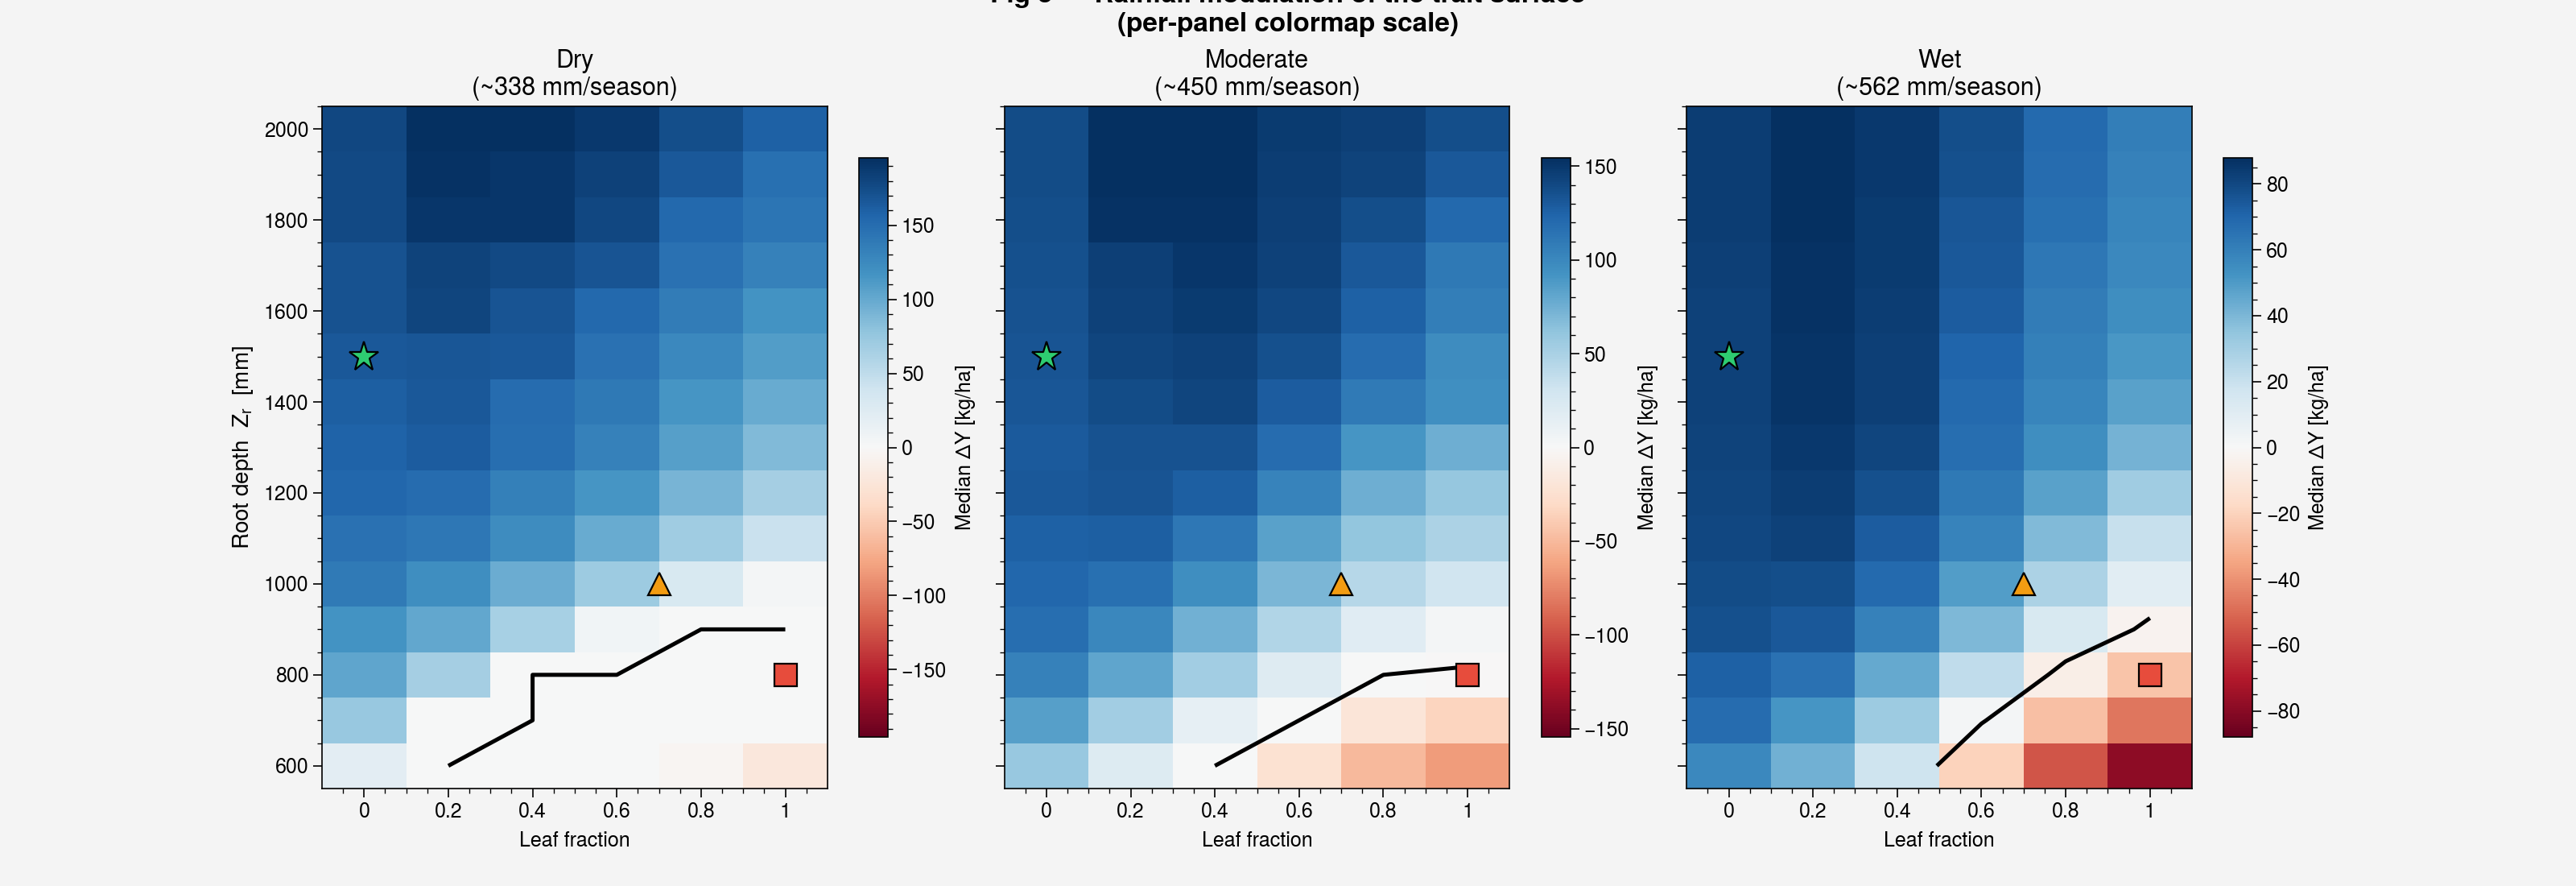

In [209]:
lf_arr = np.array(LF_VALS)
zr_arr = np.array(ZR_VALS)

# Diagnostics: confirm surfaces are not NaN and check ΔY ranges
for reg, grid in zip(REGIMES, surfaces):
    label = reg['label'].replace('\n', ' ')
    print(f"{label:30s}  min={np.nanmin(grid):+.0f}  max={np.nanmax(grid):+.0f}  "
          f"NaN={np.isnan(grid).sum()}/{grid.size}")

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

# Per-panel normalization so each regime's signal is visible
# (use shared norm for final publication figure)
for ax, grid, reg in zip(axes, surfaces, REGIMES):
    vmax = np.nanmax(np.abs(grid))
    if vmax == 0 or np.isnan(vmax):
        vmax = 1.0
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
    cmap = plt.cm.RdBu

    im = ax.pcolormesh(lf_arr, zr_arr, grid,
                       norm=norm, cmap=cmap, shading='nearest')
    ax.contour(lf_arr, zr_arr, grid, levels=[0],
               colors='k', linewidths=1.8)
    ax.set_xlabel('Leaf fraction', fontsize=9)
    ax.set_title(reg['label'], fontsize=11)
    plt.colorbar(im, ax=ax, label='Median ΔY [kg/ha]', shrink=0.85)

    for name, sp in SPECIES.items():
        ax.plot(sp['lf'], sp['Zr'], marker=sp['marker'], color=sp['color'],
                ms=sp['ms'], mec='k', mew=0.8, zorder=5)

axes[0].set_ylabel('Root depth  $Z_r$  [mm]', fontsize=10)

fig.suptitle('Fig 5 — Rainfall modulation of the trait surface\n(per-panel colormap scale)', fontsize=12, y=1.02)
plt.savefig('../output/fig5_rainfall_modulation.png', dpi=150, bbox_inches='tight')
plt.show()

Dry (~338 mm/season)            min=-22  max=+196  NaN=0/90
Moderate (~450 mm/season)       min=-66  max=+155  NaN=0/90
Wet (~562 mm/season)            min=-79  max=+88  NaN=0/90


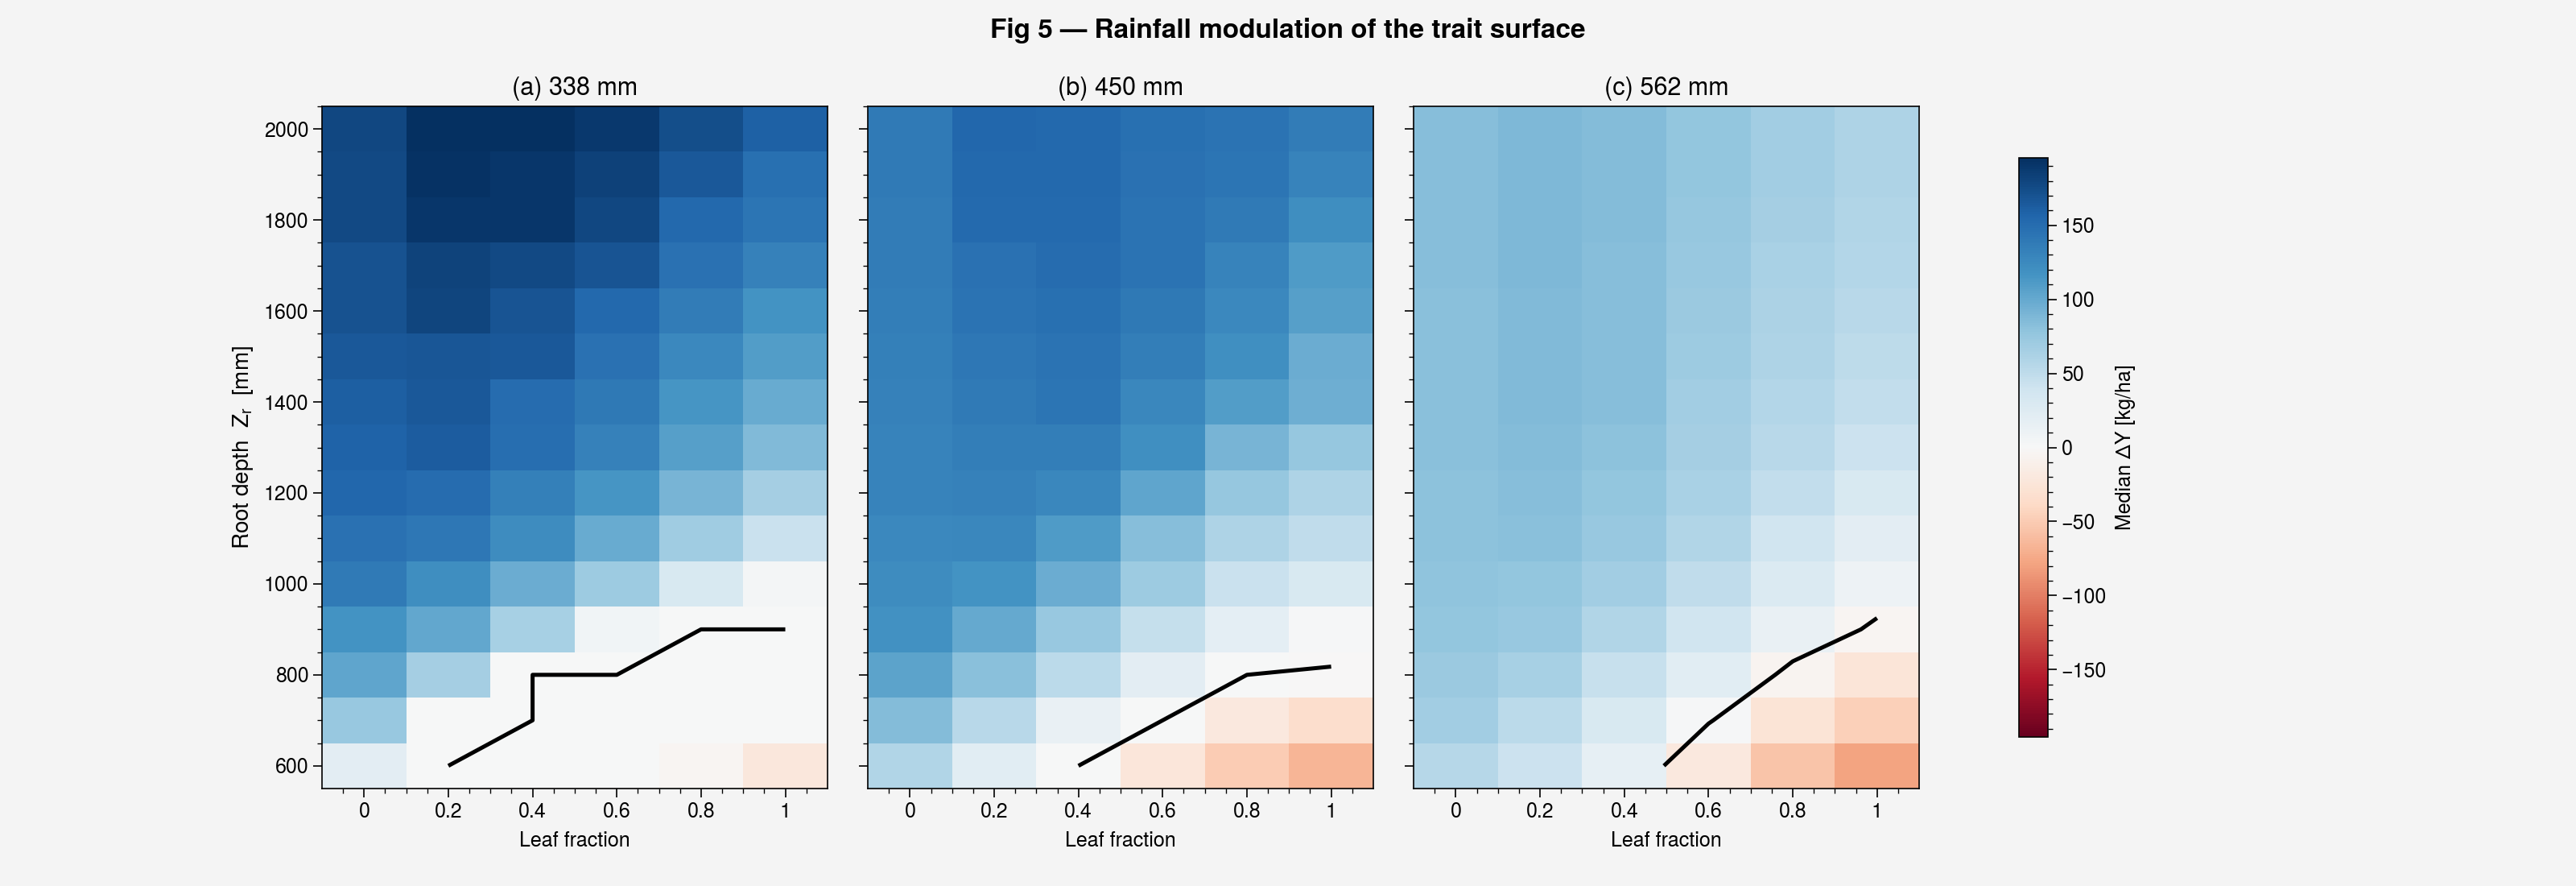

In [222]:
lf_arr = np.array(LF_VALS)
zr_arr = np.array(ZR_VALS)

# Diagnostics: confirm surfaces are not NaN and check ΔY ranges
for reg, grid in zip(REGIMES, surfaces):
    label = reg['label'].replace('\n', ' ')
    print(f"{label:30s}  min={np.nanmin(grid):+.0f}  max={np.nanmax(grid):+.0f}  "
          f"NaN={np.isnan(grid).sum()}/{grid.size}")

# --- shared normalization across all regimes ---
global_vmax = np.nanmax([np.nanmax(np.abs(g)) for g in surfaces])
if global_vmax == 0 or np.isnan(global_vmax):
    global_vmax = 1.0

norm = TwoSlopeNorm(vmin=-global_vmax, vcenter=0, vmax=global_vmax)
cmap = plt.cm.RdBu

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), sharey=True)
fig.subplots_adjust(wspace=0.08)
panel_titles = ['(a) 338 mm', '(b) 450 mm', '(c) 562 mm']


for i, (ax, grid, reg) in enumerate(zip(axes, surfaces, REGIMES)):

    im = ax.pcolormesh(
        lf_arr, zr_arr, grid,
        norm=norm, cmap=cmap, shading='nearest'
    )

    ax.contour(
        lf_arr, zr_arr, grid,
        levels=[0], colors='k', linewidths=1.8
    )

    ax.set_xlabel('Leaf fraction', fontsize=9)

    ax.set_title(panel_titles[i], fontsize=11)

    # --- species overlay (disabled) ---
    # for name, sp in SPECIES.items():
    #     ax.plot(
    #         sp['lf'], sp['Zr'],
    #         marker=sp['marker'], color=sp['color'],
    #         ms=sp['ms'], mec='k', mew=0.8, zorder=5
    #     )

axes[0].set_ylabel('Root depth  $Z_r$  [mm]', fontsize=10)

# single shared colorbar
cbar = fig.colorbar(im, ax=axes, label='Median ΔY [kg/ha]', shrink=0.85)

fig.suptitle(
    'Fig 5 — Rainfall modulation of the trait surface',
    fontsize=12
)

plt.savefig('../output/fig5_rainfall_modulation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Fig 6 — Rainfall distribution: does storm regime matter?

**Motivation:** Total rainfall (λα·t) determines *how much* water arrives. But the *distribution*
of that water — many small events vs. few large ones — controls how much percolates to s_deep and
therefore how much HR fuel is available.

**Physical mechanism:**
- High-α / low-λ (infrequent intense): large pulses push s_top > s_fc → deep percolation between
  events → s_deep recharged → strong nocturnal HR gradient → facilitation favoured.
- Low-α / high-λ (frequent light): s_top persistently moist but sub-s_fc → little percolation →
  s_deep stays dry → HR flux near zero → competition favoured.

**Design:** Two panels, both at the moderate total rainfall regime (~450 mm/season):

| Panel | alpha | lambda | Interpretation |
|-------|-------|--------|----------------|
| Left  | 20 mm | 0.125/day | Infrequent intense storms (semi-arid convective) |
| Right |  5 mm | 0.500/day | Frequent light rain (highland drizzle) |

Same `leaf_fraction × Zr` axes as Fig 4. Full mechanisms (deep roots + HR + shade). N=200.

**Key question:** Does the competition-facilitation zero-contour shift between storm regimes?
Which trait combinations are most sensitive to rainfall distribution vs. total amount?

In [183]:
# ── Fig 6 compute: rainfall distribution at fixed total ───────────────────────
# Both regimes match the moderate total: alpha * lambda * 180 ≈ 450 mm/season
DIST_REGIMES = [
    dict(label='Infrequent intense\n(α=20 mm, λ=0.125/day)', alpha=20.0, lam=0.125),
    dict(label='Frequent light\n(α=5 mm, λ=0.50/day)',       alpha=5.0,  lam=0.500),
]

# Verify means
for dr in DIST_REGIMES:
    print(f'{dr["label"].split(chr(10))[0]:30s}  '
          f'mean seasonal RF = {dr["alpha"] * dr["lam"] * 180:.0f} mm')

surfaces_dist = []
for dr in DIST_REGIMES:
    climate_d = Climate()
    # Both alpha_r and lambda_r are indexed as arrays in Climate.generate(alpha_r[doy-1], ...)
    climate_d.alpha_r  = np.array([dr['alpha']] * 365)
    climate_d.lambda_r = np.array([dr['lam']]   * 365)

    grid = np.full((len(ZR_VALS), len(LF_VALS)), np.nan)
    for i, zr in enumerate(ZR_VALS):
        for j, lf in enumerate(LF_VALS):
            tp = {**BASE_PARAMS, 'Zr': zr, 'leaf_fraction': lf}
            dY = _dY_array(tp, climate_d, seeds,
                           shade_on=True, hr_on=True, deep_roots=True)
            grid[i, j] = np.median(dY)
    surfaces_dist.append(grid)
    print(f'{dr["label"].replace(chr(10), " ")} done.')

Infrequent intense              mean seasonal RF = 450 mm
Frequent light                  mean seasonal RF = 450 mm
Infrequent intense (α=20 mm, λ=0.125/day) done.
Frequent light (α=5 mm, λ=0.50/day) done.


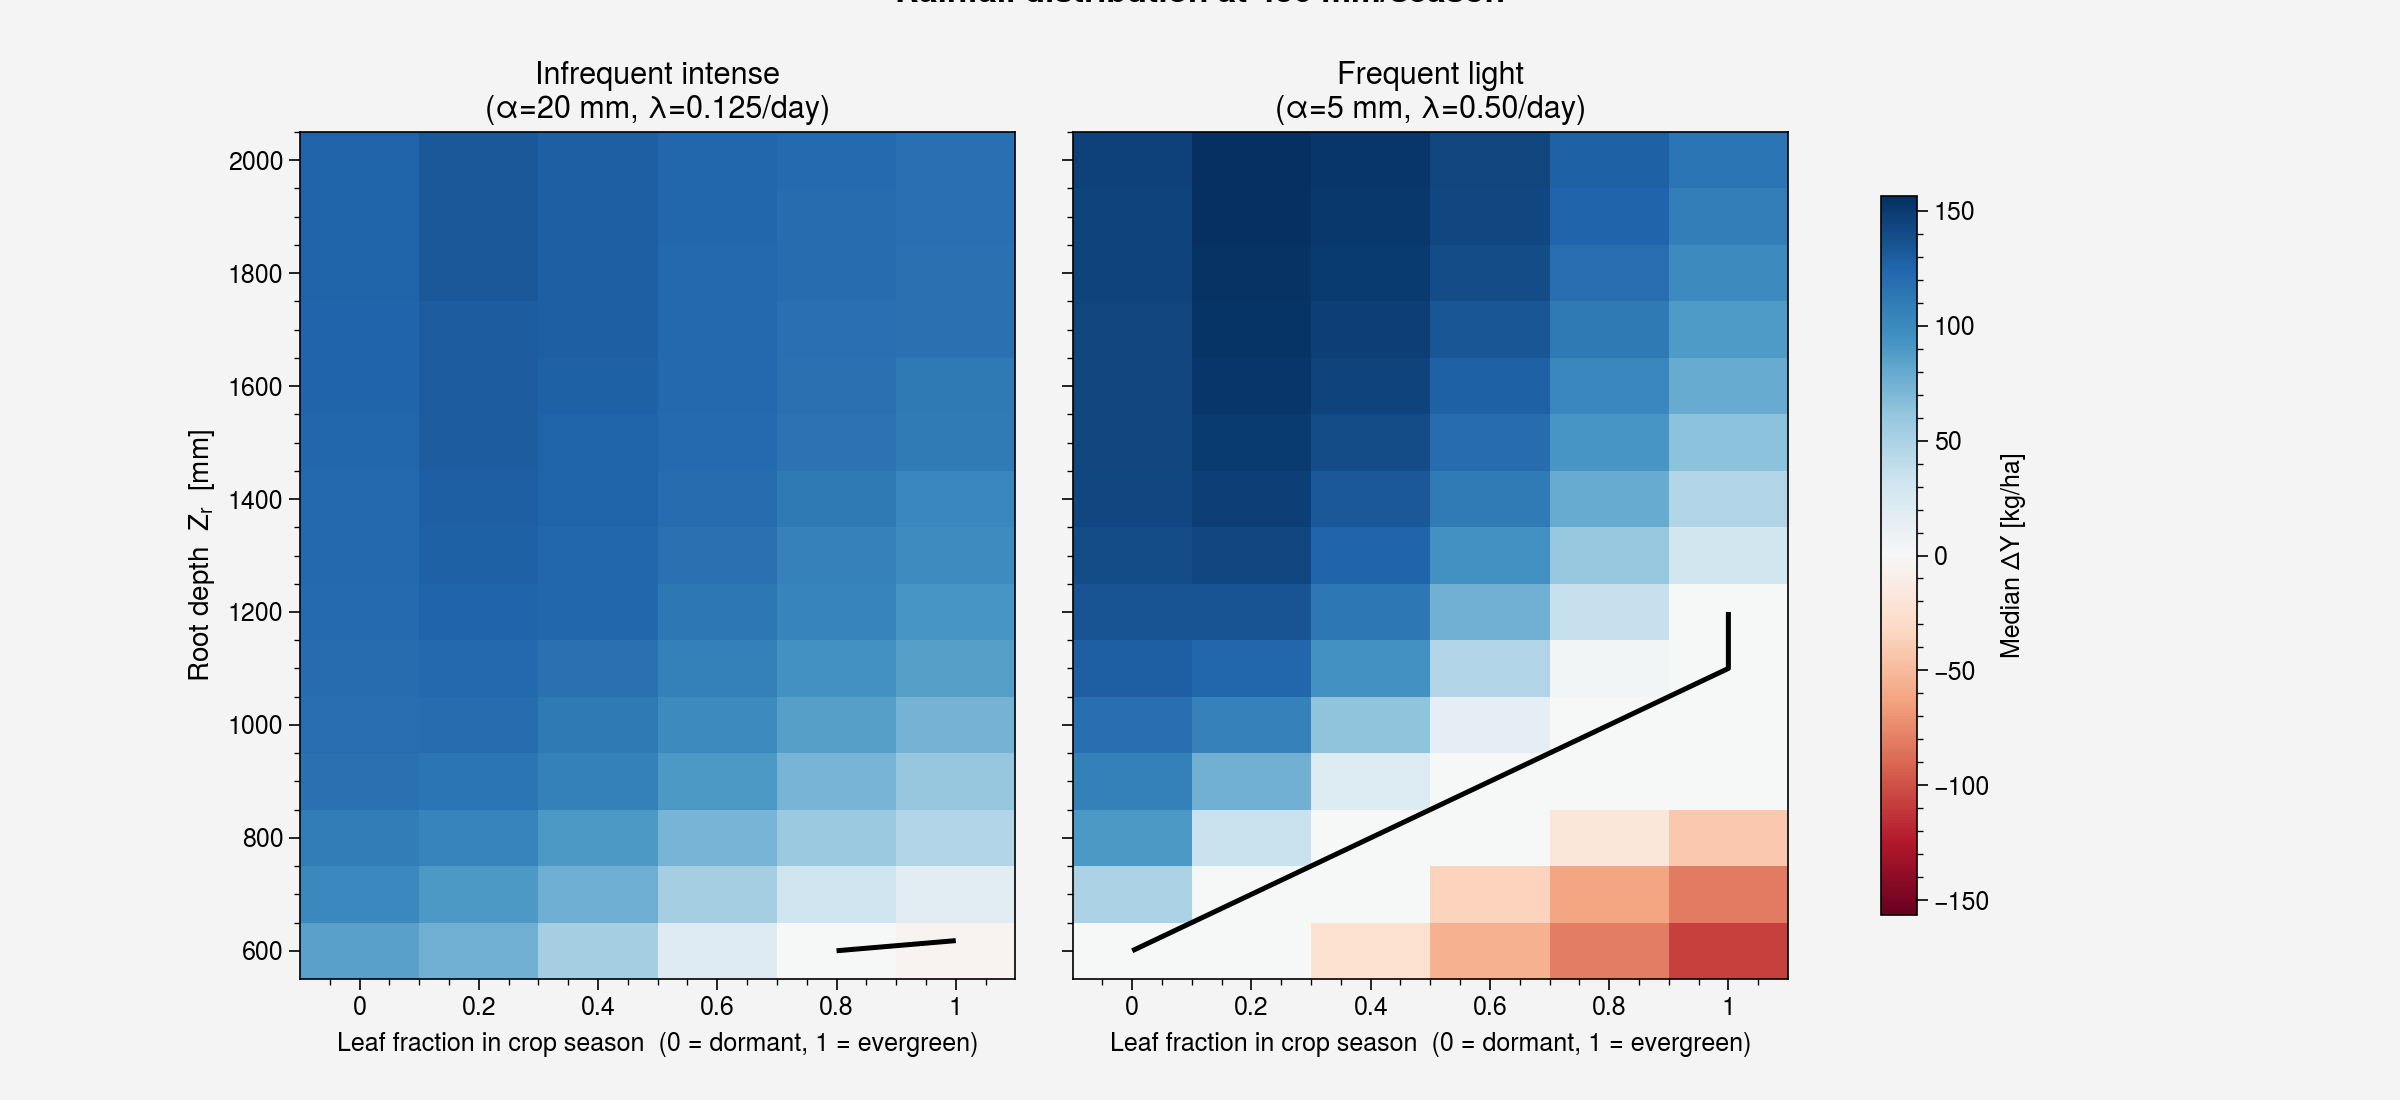

In [227]:
lf_arr = np.array(LF_VALS)
zr_arr = np.array(ZR_VALS)

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5), sharey=True)
fig.subplots_adjust(wspace=0.08)

# Shared colormap range across both panels
vmax = max(np.nanmax(np.abs(surf)) for surf in surfaces_dist)
if vmax == 0 or np.isnan(vmax):
    vmax = 1.0

norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cmap = plt.cm.RdBu

for ax, grid, dr in zip(axes, surfaces_dist, DIST_REGIMES):

    im = ax.pcolormesh(
        lf_arr, zr_arr, grid,
        norm=norm, cmap=cmap, shading='nearest'
    )

    ax.contour(
        lf_arr, zr_arr, grid,
        levels=[0], colors='k', linewidths=1.8
    )

    ax.set_xlabel(
        'Leaf fraction in crop season  (0 = dormant, 1 = evergreen)',
        fontsize=9
    )

    ax.set_title(dr['label'], fontsize=11)

axes[0].set_ylabel('Root depth  $Z_r$  [mm]', fontsize=10)

# --- single shared colorbar ---
cbar = fig.colorbar(im, ax=axes, label='Median ΔY [kg/ha]', shrink=0.85)

fig.suptitle(
    'Rainfall distribution at 450 mm/season',
    fontsize=12, y=1.02
)

plt.savefig('../output/fig6_rainfall_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Notes and open questions

### Known limitations

**1. s_deep_0 does not reflect dry-season tree behavior.**
`leaf_fraction` only controls tree phenology during the 180-day crop season. Both lf=0 and lf=1 trees start with the same fixed `s_deep_0`, regardless of what the tree was doing in the preceding dry season. In reality:
- lf=0 (Faidherbia): leafy pre-season (reverse phenology) → s_deep depleted at crop season start
- lf=1 (evergreen): leafy year-round → s_deep also depleted at crop season start
- Monoculture: no tree demand → s_deep recharged by gravity drainage only

This likely underestimates the HR signal for Faidherbia (which enters the rainy season with dry deep roots, amplifying the nightly gradient). Fix: pre-season spin-up to compute realistic s_deep_0 per archetype. Flagged for future work.

**2. Closed vadose zone / no groundwater.**
Faidherbia is a facultative phreatophyte drawing from the water table at 3–19 m. Our deep layer (500–1500 mm) represents the vadose zone only. Pre-season deep-layer depletion in the annual-cycle model is likely an artifact; the real tree draws from a continuously recharged groundwater reservoir. See CLAUDE.md §3d.

**3. ET_max is a fixed constant.**
The climate model uses ET_max=6.5 mm/day regardless of season, temperature, or VPD. Aridity can only be represented through λ and α (rainfall frequency/depth), not through atmospheric demand.

---

### Parameter choices to revisit
- `T_MAX=1.0` for all grid cells. Realistic across Zr values?
- `canopy_cover=0.2` held constant — consider supplementary figure varying this.
- Species Zr values (Grevillea, Leucaena) — need literature confirmation.

### Sensitivity (supplementary)
- `hr_max` sweep: 0.0, 0.5, 1.0, 2.0 mm/day
- `canopy_cover` sweep: 0.1, 0.2, 0.3, 0.4
- N-fixation bonus: `Y_MAX *= (1 + N_bonus)`, N_bonus ∈ [0, 0.15]

### Validation
- Compare labeled species ΔY against field observations (Bayala et al., Garrity et al., Ong et al.)
- Faidherbia target: +10–30% yield gain (literature range, includes N-fixation)
- Grevillea target: −20 to −50% (Ong et al. 2000)